# E-Commerce Sales Analysis — Python EDA

**Day 4 of 7-Day Data Analyst Portfolio Project**

---

### About This Notebook
This notebook contains Exploratory Data Analysis (EDA) using Python on the e-commerce sales dataset cleaned on Day 1. This analysis builds on the findings from Day 2 (Excel) and Day 3 (SQL), focusing on statistical exploration, data distribution, and visualization using pandas, matplotlib, and seaborn.

| | |
|---|---|
| **Author** | Alya Shandy |
| **Dataset** | `cleaned_sales_data.csv` (3,933 rows, cleaned on Day 1) |
| **Tools** | Python, pandas, numpy, matplotlib, seaborn |
| **Stage** | Day 4 — Python EDA |

---

## Table of Contents
1. [Import Library & Load Dataset](#1)
2. [Data Overview & Structure](#2)
3. [Descriptive Statistics](#3)
4. [Revenue & Quantity Distribution](#4)
5. [Category & Region Analysis](#5)
6. [Time Series Analysis](#6)
7. [Correlation Between Variables](#7)
8. [EDA Conclusion](#8)


## 1. Import Library & Load Dataset

Importing the required libraries and loading the cleaned dataset from Day 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Set pandas display: show only the first 5 and last 5 rows
pd.set_option('display.max_rows', 10)

# Load the cleaned dataset from Day 1
df = pd.read_csv('../cleaned_sales_data.csv')

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df

Dataset loaded successfully!
Rows: 3933, Columns: 12


,order_id,order_date,customer_id,customer_name,region,category,product_name,quantity,unit_price,order_status,payment_method,revenue
0,ORD100363,6/17/2023,CUST1454,Fajar Wijaya,East,Beauty,Lip Balm,1,6.00,Completed,Gift Card,6.00
1,ORD101186,10/17/2024,CUST1674,Dewi Lee,East,Beauty,Lip Balm,1,6.22,Completed,Gift Card,6.22
2,ORD101364,7/11/2024,CUST1201,Linda Johnson,East,Beauty,Shampoo,2,6.22,Completed,Credit Card,12.44
3,ORD102845,11/20/2023,CUST1361,Rina Brown,East,Beauty,Moisturizer,2,6.27,Completed,Debit Card,12.54
4,ORD102156,1/11/2024,CUST1798,Siti Anderson,East,Beauty,Lip Balm,1,6.38,Completed,Gift Card,6.38
...,...,...,...,...,...,...,...,...,...,...,...,...
3928,ORD101033,7/8/2024,CUST1488,John Taylor,East,Electronics,Wireless Mouse,1,147.44,Completed,PayPal,147.44
3929,ORD101257,10/31/2024,CUST1065,Lisa Tan,East,Electronics,Power Bank,2,148.00,Completed,PayPal,296.00
3930,ORD102960,4/13/2023,CUST1475,Ayu Taylor,South,Electronics,Laptop Stand,2,148.37,Completed,PayPal,296.74
3931,ORD103884,10/8/2023,CUST1876,John Hidayat,East,Electronics,Power Bank,4,148.55,Completed,Unknown,594.20


## 2. Data Overview & Structure

Checking data types, missing values, and general dataset structure info.

In [2]:
# General info: data type per column, non-null count, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3933 entries, 0 to 3932
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        3933 non-null   object 
 1   order_date      3933 non-null   object 
 2   customer_id     3933 non-null   object 
 3   customer_name   3933 non-null   object 
 4   region          3933 non-null   object 
 5   category        3933 non-null   object 
 6   product_name    3933 non-null   object 
 7   quantity        3933 non-null   int64  
 8   unit_price      3933 non-null   float64
 9   order_status    3933 non-null   object 
 10  payment_method  3933 non-null   object 
 11  revenue         3933 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 368.8+ KB


In [3]:
# Check missing values per column
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


order_id          0
order_date        0
customer_id       0
customer_name     0
region            0
                 ..
quantity          0
unit_price        0
order_status      0
payment_method    0
revenue           0
Length: 12, dtype: int64

In [4]:
# Check number of duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


**Insight:** The dataset is confirmed fully clean — 0 missing values and 0 duplicate rows across all 12 columns, the result of the cleaning work done on Day 1. However, the `order_date` column is still typed as `object` (text), not `datetime` — this is consistent with the finding in Day 3 SQL, where this column needed to be converted first (using `pd.to_datetime()` in Python, or `STR_TO_DATE()` in SQL) before it could be used for time-based analysis. Since there's no missing or duplicate data, all 3,933 rows can be used directly for further analysis without additional cleaning.

## 3. Descriptive Statistics

Statistical summary for numeric columns (quantity, unit_price, revenue) and categorical columns.

In [5]:
# Descriptive statistics for numeric columns
df[['quantity', 'unit_price', 'revenue']].describe()

,quantity,unit_price,revenue
count,3933.000000,3933.000000,3933.00000
mean,1.638444,47.207752,78.01734
std,0.994628,31.307818,78.24140
min,1.000000,6.000000,6.00000
25%,1.000000,23.330000,29.56000
50%,1.000000,38.210000,52.84000
75%,2.000000,64.170000,96.64000
max,5.000000,149.710000,735.55000


**Insight:** The quantity column has a narrow range (1-5 units) with a mean of 1.64 — confirming that most orders only purchase a small number of units. The unit_price column has a wide range (USD 6 - USD 149.71) with a notable gap between the median (USD 38.21) and mean (USD 47.21), indicating a few expensive products pull the average upward. The revenue column shows a similar but more extreme pattern — the gap between the median (USD 52.84) and max (USD 735.55) is much larger, since revenue is the product of quantity × unit_price, so transactions combining "large quantity + high price" can produce values far above average.

In [6]:
# Statistics for categorical columns: number of unique values per column
categorical_cols = ['region', 'category', 'product_name', 'order_status', 'payment_method']

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

region: 4 unique values
category: 7 unique values
product_name: 43 unique values
order_status: 4 unique values
payment_method: 5 unique values


**Insight:** The dataset has a fairly simple categorical structure — only 4 regions, 7 product categories, and 5 payment methods, making it easy to analyze without needing additional grouping. The product_name column has higher variation (43 unique products), enough for a meaningful Top/Bottom Products analysis, yet still manageable since it all falls under the same 7 umbrella categories. order_status, with 4 unique values (Completed, Cancelled, Returned, Pending), is a key column that determines the filter used across almost every revenue analysis throughout this project.

In [7]:
# Detail breakdown of each categorical column
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- region ---
East       2926
Midwest     784
South       182
West         41
Name: region, dtype: int64

--- category ---
Sports & Outdoors    576
Home & Kitchen       572
Beauty               567
Electronics          565
Clothing             557
Books                554
Toys                 542
Name: category, dtype: int64

--- product_name ---
Children's Book     121
Lip Balm            120
Face Mask Set       118
Moisturizer         117
Camping Tent        115
                   ... 
Blender              72
Power Bank           69
USB-C Cable          66
Wireless Mouse       62
Wireless Earbuds     60
Name: product_name, Length: 43, dtype: int64

--- order_status ---
Completed    3220
Cancelled     314
Returned      240
Pending       159
Name: order_status, dtype: int64

--- payment_method ---
PayPal         955
Credit Card    945
Gift Card      940
Debit Card     935
Unknown        158
Name: payment_method, dtype: int64


**Insight:** The East region dominates dramatically with 2,926 out of 3,933 orders (74.4%) — consistent with the revenue findings in Day 3, confirming this imbalance is not just about transaction value but also order volume. From order_status, only 3,220 out of 3,933 orders (81.9%) are Completed — the remaining 18.1% are Cancelled, Returned, or Pending, which explains why the "gross" revenue figure in Section 5 later will be higher than the Completed-only revenue figure from Day 3 SQL. Meanwhile, payment methods are fairly evenly distributed (PayPal, Credit Card, Gift Card, Debit Card all sit between 900-955), except for the "Unknown" category (158 orders), which flags some payment method data that wasn't captured — not technically a missing value, but still worth noting as a data quality remark.

## 4. Revenue & Quantity Distribution

Visualizing the distribution of revenue and quantity using a histogram and boxplot to see the data spread and detect outliers.

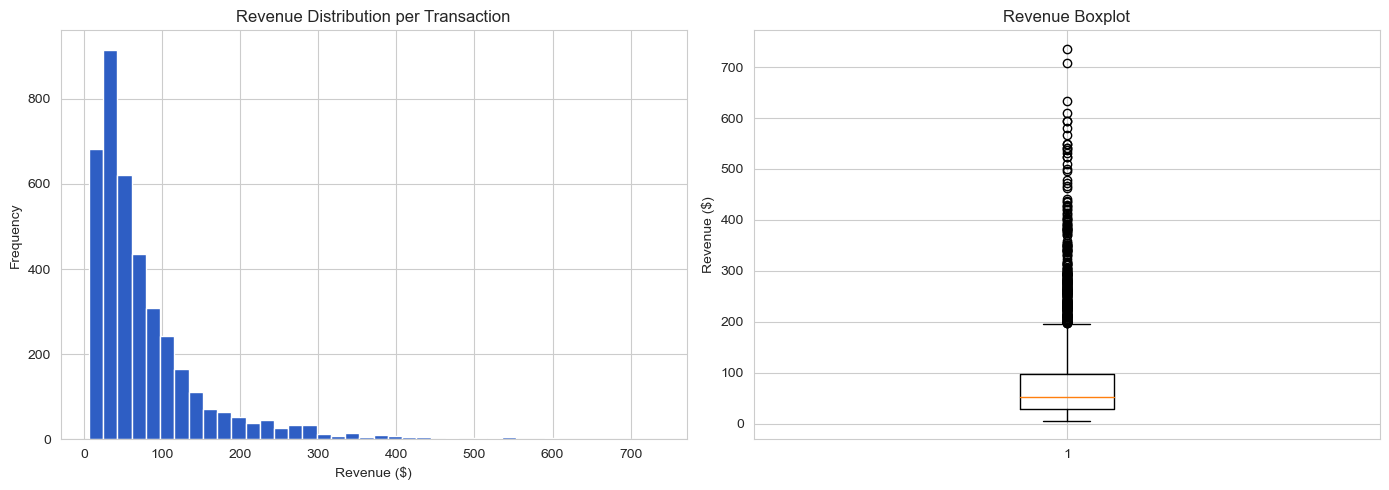

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of revenue distribution
axes[0].hist(df['revenue'], bins=40, color='#2E5EC4', edgecolor='white')
axes[0].set_title('Revenue Distribution per Transaction')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Frequency')

# Boxplot of revenue to spot outliers
axes[1].boxplot(df['revenue'], vert=True)
axes[1].set_title('Revenue Boxplot')
axes[1].set_ylabel('Revenue ($)')

plt.tight_layout()
plt.show()

**How to read this chart:**
- **Histogram (left):** the X-axis = revenue value range (per USD 20), the Y-axis = number of transactions in that range. The tallest bar sits around USD 20-40 with a height of ~900 — meaning about 900 transactions fall in that range. Moving further right (toward USD 700), the bars get shorter/nearly flat against the X-axis — meaning fewer and fewer transactions reach that high a value.
- **Boxplot (right):** the box at the bottom (around USD 30-100) represents the 50% most common transactions. The orange line inside the box is the median (USD 52.84). The circular dots above the USD 195 line are outliers — each dot represents one individual transaction with a value far above most others, clustering densely from USD 200-500 and then thinning out up to the highest point at USD 735.55.

**Insight:** The distribution of revenue per transaction is strongly *right-skewed* — most transactions are valued below USD 100, with a peak (mode) around USD 30-50. The long tail to the right and many outliers in the boxplot (transactions above USD 200, up to a maximum of USD 735.55) show that a small subset of transactions are worth far more than average — likely from a combination of expensive products (high unit_price) with a quantity greater than 1. This pattern is consistent with the mean revenue (USD 78.02) being much higher than the median (USD 52.84), a hallmark of skewed data.

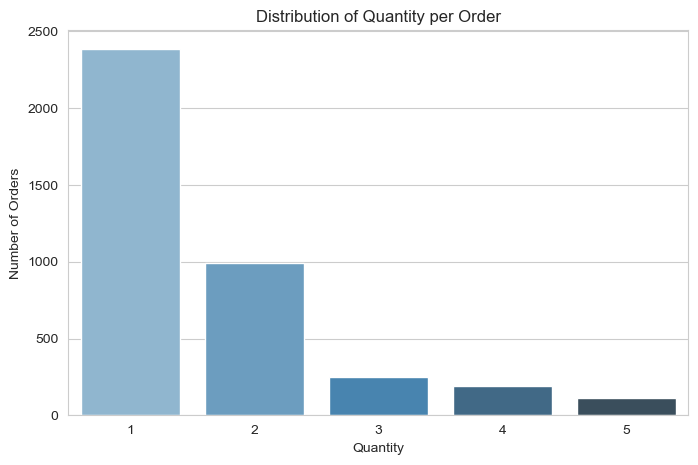

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='quantity', palette='Blues_d')
plt.title('Distribution of Quantity per Order')
plt.xlabel('Quantity')
plt.ylabel('Number of Orders')
plt.show()

**Insight:** The majority of orders (around 60%) purchase only 1 unit of product, and order count decreases consistently as quantity increases — orders with 5 units are the rarest. This pattern reinforces the finding from Query 13 in Day 3: the low Average Order Value (USD 78.33) isn't just about cheap product pricing, but also because most transactions are single-item purchases. This strengthens the case for a bundling/cross-sell strategy — encouraging customers to buy more than 1 unit or more than 1 product at once could meaningfully raise AOV.

## 5. Category & Region Analysis

Visualizing revenue by product category and region to identify the main sales contributors.

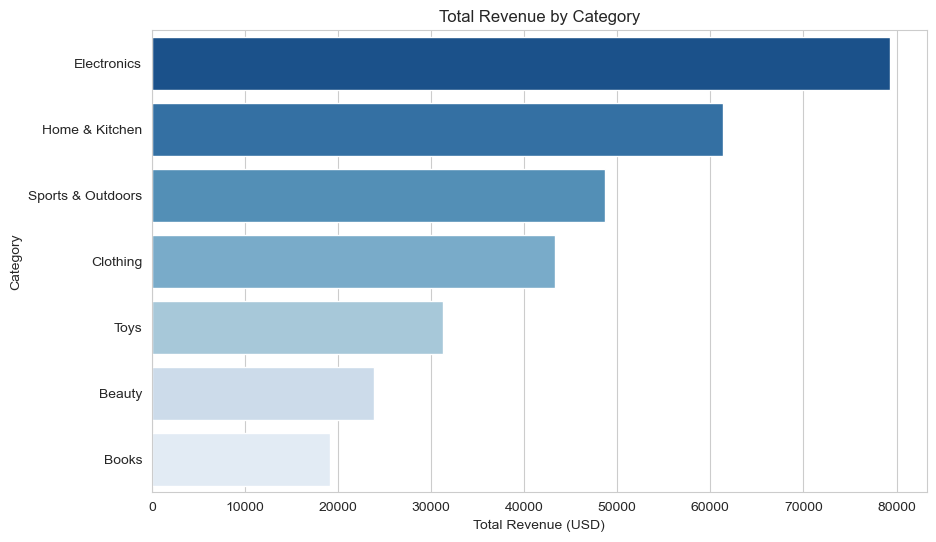

In [10]:
# Revenue by category
category_revenue = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='Blues_r')
plt.title('Total Revenue by Category')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Category')
plt.show()

**Insight:** Electronics is the category with the highest revenue (around USD 80,000), well ahead of Home & Kitchen in second place. Books sits at the bottom with the smallest revenue. Note that the figures in this chart count **all orders** (including Cancelled/Returned/Pending), not just Completed ones as in the Day 3 SQL analysis — so the values are higher than the Query 12 figure (USD 63,888 for Electronics), but the ranking order stays exactly the same. This is additional validation that Electronics is consistently the strongest category, under any condition.

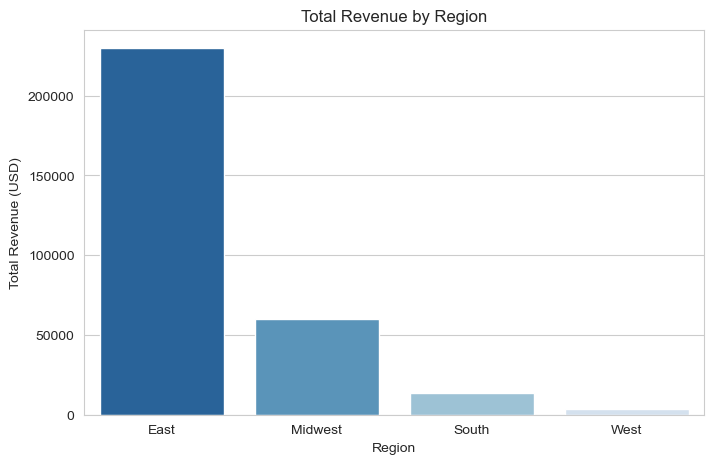

In [11]:
# Revenue by region
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_revenue.index, y=region_revenue.values, palette='Blues_r')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue (USD)')
plt.show()

**Insight:** The East region dominates dramatically with revenue approaching USD 230,000, far outpacing Midwest, South, and West, which are barely visible on the chart. This extreme imbalance is consistent with the Query 7 finding in Day 3 (East = 74.4% of Completed revenue) — and now it's clearly visualized that the gap isn't just large in percentage terms, but also in absolute scale. The West region, barely visible in this chart, is a strong signal that expanding beyond East is both one of the riskiest and most promising areas for this business.

## 6. Time Series Analysis

Visualizing the monthly revenue trend across the full data period (Jan 2023 - Dec 2024) to see growth and seasonality patterns.

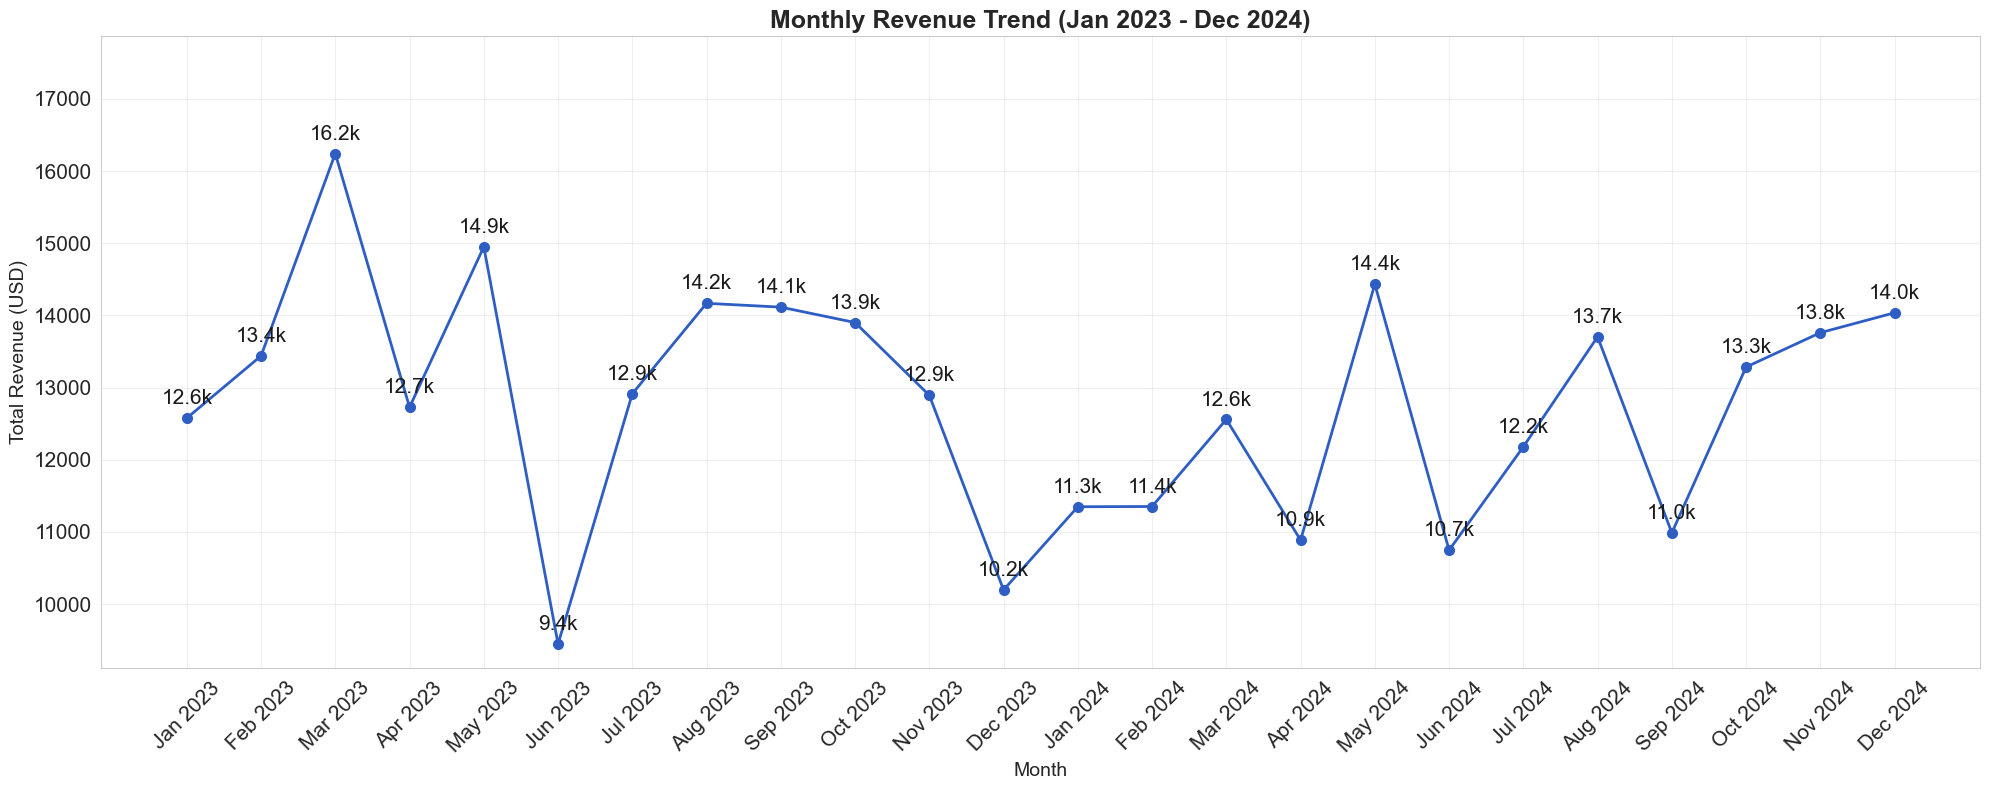

In [12]:
# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%Y')
df['year_month'] = df['order_date'].dt.to_period('M')

monthly_revenue = df.groupby('year_month')['revenue'].sum()

# Convert index to plain string (e.g. "Jan 2023") so all labels are consistent
monthly_revenue.index = monthly_revenue.index.strftime('%b %Y')

plt.figure(figsize=(20, 8))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='#2E5EC4', linewidth=2, markersize=7)
plt.title('Monthly Revenue Trend (Jan 2023 - Dec 2024)', fontsize=18, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Revenue (USD)', fontsize=14)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, alpha=0.3)

# Add extra headroom so the value labels don't get cut off
plt.ylim(top=monthly_revenue.max() * 1.1)

# Add a value label above each point
for i, value in enumerate(monthly_revenue.values):
    plt.annotate(f'{value/1000:.1f}k',
                 (i, value),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=15,
                 color='#1A1A1A')

plt.tight_layout()
plt.show()

**Insight:** The monthly revenue trend shows a sharp, repeating up-and-down pattern across 24 months, with no consistent seasonal direction — the highest peak occurred in March 2023 (USD 16.2k) and the lowest point in June 2023 (USD 9.4k), a difference of nearly double within just a three-month span. Similar volatile patterns (sharp rise then sharp drop) repeat several times, for example April-June 2024 (14.4k dropping to 10.7k) and July-September 2024 (13.7k dropping to 11.0k). This visualization serves as direct visual evidence for the Query 11 finding in Day 3 (MoM growth ranging from -42.88% to +54.08%) — monthly revenue doesn't follow a predictable seasonal pattern, likely driven more by operational or random factors than by a long-term trend.

## 7. Correlation Between Variables

Looking at the relationship between numeric variables (quantity, unit_price, revenue) using a correlation heatmap.

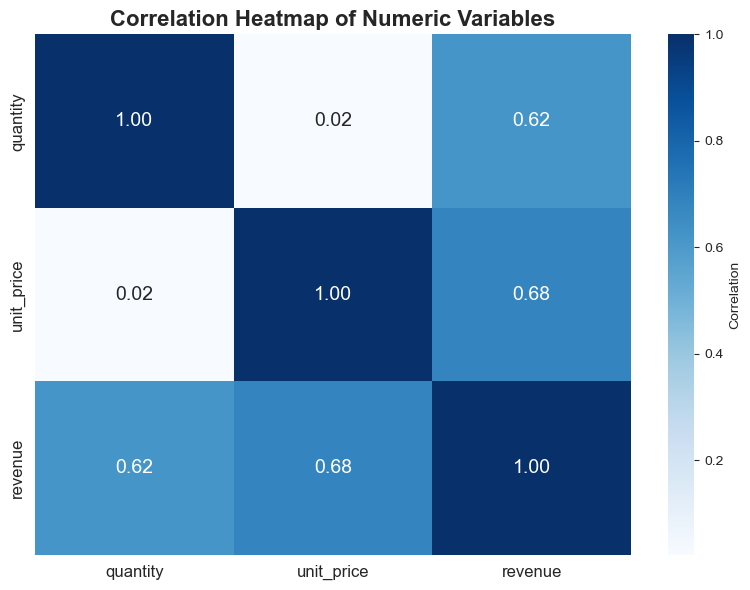

In [13]:
# Calculate the correlation matrix
corr_matrix = df[['quantity', 'unit_price', 'revenue']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f',
            annot_kws={'size': 14}, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap of Numeric Variables', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** Revenue correlates fairly strongly with unit_price (0.68) and quantity (0.62) — both are meaningful drivers of revenue, with product price slightly more dominant. Interestingly, the correlation between unit_price and quantity itself is nearly zero (0.02), meaning customers don't tend to buy more units when a product is cheaper (or vice versa) — the decisions of "how many to buy" and "which product to choose" appear independent of each other. This reinforces the insight from Section 4: since most orders are just 1 unit (independent of product price), raising revenue is more realistically achieved through a cross-sell/bundling approach (increasing the number of items per transaction) rather than expecting customers to automatically buy more when a product is cheap.

## 8. EDA Conclusion

Summary of the key findings from the data exploration using Python.

In [14]:
summary = {
    'Total Rows': df.shape[0],
    'Total Columns': df.shape[1],
    'Missing Values': df.isnull().sum().sum(),
    'Duplicate Rows': df.duplicated().sum(),
    'Average Revenue': f"USD {df['revenue'].mean():.2f}",
    'Median Revenue': f"USD {df['revenue'].median():.2f}",
    'Top Category': category_revenue.idxmax(),
    'Top Region': region_revenue.idxmax(),
    'Revenue-Unit Price Correlation': f"{corr_matrix.loc['revenue', 'unit_price']:.2f}",
    'Revenue-Quantity Correlation': f"{corr_matrix.loc['revenue', 'quantity']:.2f}",
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df

,Metric,Value
0,Total Rows,3933
1,Total Columns,13
2,Missing Values,0
3,Duplicate Rows,0
4,Average Revenue,USD 78.02
5,Median Revenue,USD 52.84
6,Top Category,Electronics
7,Top Region,East
8,Revenue-Unit Price Correlation,0.68
9,Revenue-Quantity Correlation,0.62


### Key Findings Summary

This Python-based data exploration on the 3,933-row dataset reinforces and enriches the findings from Day 2 (Excel) and Day 3 (SQL) with a deeper statistical and visual perspective:

1. **Revenue distribution is strongly right-skewed** — most transactions are low value (under USD 100), with a few high outliers (maximum USD 735.55) pulling the average (USD 78.02) well above the median (USD 52.84).

2. **Most orders are single-item purchases** — around 60% of orders buy only 1 unit of product, explaining why Average Order Value stays low despite a fairly wide product price range (USD 6 - USD 149.71).

3. **Electronics and the East region remain dominant** across every angle of analysis — consistent with the Day 3 SQL findings, reinforcing the reliability of that insight across analysis methods.

4. **Monthly trends are highly volatile with no clear seasonal pattern** — the time series visualization visually confirms the wild MoM growth findings from Day 3 (-42.88% to +54.08%).

5. **Revenue is driven fairly evenly by price and quantity** (correlation 0.68 and 0.62), yet the two are nearly independent of each other (correlation 0.02) — customers don't automatically buy more when prices are lower, reinforcing the bundling/cross-sell opportunity.

This notebook completes the Day 1-3 analysis series and lays the groundwork for the next stage: **Day 5 — Tableau Dashboard**, where these findings will be visualized as an interactive dashboard for business stakeholders.

---
*Notebook by Alya Shandy — Day 4 of 7-Day Data Analyst Portfolio Project*